In [16]:
# ==============================================================================
# 🛠️ CELL 1: SETUP & CONFIGURATION
# ==============================================================================
import os
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import shape
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import autogen
from dotenv import load_dotenv

# Import Overture Logic from Utl.py
try:
    from Utl import acs_county_data, process_locs_buildings
    print("✅ Loaded Utl.py successfully.")
except ImportError:
    print("❌ Utl.py not found. Please ensure it is in the same folder.")

load_dotenv()
API_KEY = os.getenv("OPENAI_API_KEY", "")
API_BASE = "https://api.ai.it.cornell.edu/"

if not API_KEY:
    raise ValueError("OPENAI_API_KEY not found in .env file")

# Update this with your OpenAI API key from .env
config_list = [{"model": "openai.gpt-5-mini", "api_key": API_KEY, "base_url": API_BASE}]

# Paper Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.4)

✅ Loaded Utl.py successfully.


In [17]:
# ==============================================================================
# 📊 CELL 2: THE DEMOGRAPHER (ROBUST DATA INGESTION)
# ==============================================================================
class Demographer:
    def __init__(self):
        self.profiles = {} 

    def ingest_census(self, city_name, county_code, state_code):
        print(f"\n📥 [DEMOGRAPHER] Fetching Real ACS Data for {city_name}...")
        
        # 1. Fetch from Census API
        try:
            acs_county_data(county_code, state_code) # Saves to CSV
        except Exception as e:
            print(f"   ⚠️ API Warning: {e} (Attempting to read cached CSV)")

        # 2. Process Data
        fpath = f"ACS/{state_code}_{county_code}.csv"
        if os.path.exists(fpath):
            df = pd.read_csv(fpath)
            
            # Find Age Column dynamically based on mapping
            col_age = next((c for c in df.columns if 'Age' in c or 'B01002' in c), None)
            
            if col_age:
                # --- FIX: Handle Sparse Data ---
                if len(df) < 17:
                    # Upsample if not enough tracts to fill the grid
                    df = df.sample(n=17, replace=True).reset_index(drop=True)
                    df['zone_id'] = [f"Region {i}" for i in range(17)]
                else:
                    # Use pd.cut (Equal Interval) instead of qcut to prevent bin errors
                    df = df.sort_values(by=col_age).reset_index(drop=True)
                    df['zone_id'] = pd.cut(df.index, bins=17, labels=[f"Region {i}" for i in range(17)])

                grouped = df.groupby('zone_id')[[col_age]].mean()
                
                # Assign Sociological Cohort
                def get_cohort(age):
                    if pd.isna(age): return "Family"
                    if age < 34: return "Young Urban"
                    elif age < 48: return "Family"
                    else: return "Senior"
                
                grouped['cohort'] = grouped[col_age].apply(get_cohort)
                self.profiles[city_name] = grouped.to_dict('index')
                print(f"   ✅ Mapped {len(grouped)} zones to cohorts using Real Census Data.")
                return self.profiles[city_name]
        
        print("   ❌ Failed. Check ACS/ folder or API Key.")
        return {}

demo = Demographer()

In [18]:
# ==============================================================================
# 🧠 CELL 3: THE SOCIOLOGIST (INTENT GENERATION)
# ==============================================================================
class SociologistAgent:
    def __init__(self):
        # FIX: Added code_execution_config=False to prevent Docker error
        self.agent = autogen.AssistantAgent("Sociologist", llm_config={"config_list": config_list}, system_message="JSON Only.")
        self.user = autogen.UserProxyAgent(
            "user", 
            human_input_mode="NEVER", 
            max_consecutive_auto_reply=0,
            code_execution_config=False  # <--- THIS FIXES THE ERROR
        )
        self.schedules = {} 

    def generate_schedules(self, city_name, profiles):
        if not profiles: return {}
        cohorts = set(p['cohort'] for p in profiles.values())
        print(f"\n🧠 [SOCIOLOGIST] Modeling Lifestyles for {len(cohorts)} Cohorts...")
        
        for cohort in cohorts:
            prompt = f"""
            Context: {city_name}. Demographic: '{cohort}'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {{"0": {{"sleep": 0.9, ...}}, ...}}
            """
            try:
                res = self.user.initiate_chat(self.agent, message=prompt)
                data = json.loads(res.chat_history[-1]['content'].replace("```json","").replace("```","").strip())
                self.schedules[f"{city_name}_{cohort}"] = data
            except: pass
        return self.schedules

soc = SociologistAgent()

In [19]:
# ==============================================================================
# 🚦 CELL 4: THE MOBILITY PLANNER (REASONING ENGINE)
# ==============================================================================
class MobilityPlanner:
    def __init__(self):
        # FIX: Added code_execution_config=False here too
        self.agent = autogen.AssistantAgent("Planner", llm_config={"config_list": config_list}, system_message="Output JSON.")
        self.user = autogen.UserProxyAgent(
            "user", 
            human_input_mode="NEVER", 
            max_consecutive_auto_reply=0,
            code_execution_config=False # <--- THIS FIXES THE ERROR
        )
        self.cache = {}

    def decide_forces(self, city_name, hour, day_type, schedules):
        cache_key = f"{city_name}_{day_type}_{hour}"
        if cache_key in self.cache: return self.cache[cache_key]
        
        # Aggregate City State
        summary = []
        for key, sched in schedules.items():
            if city_name in key:
                cohort = key.split('_')[1]
                acts = sched.get(str(hour), {})
                top = max(acts, key=acts.get)
                summary.append(f"{cohort}: {top} ({acts[top]:.2f})")
        context_str = "; ".join(summary)

        print(f"   🧠 [PLANNER] Reasoning for {city_name} @ {hour}:00...")
        
        prompt = f"""
        City: {city_name}, {day_type}, Hour {hour}.
        State: {context_str}.
        Task: 
        1. Analyze cultural/temporal drivers.
        2. Output 3 'Mobility Forces' (0.0-1.0).
        Output JSON: {{"reasoning": "...", "forces": {{"commute": <float>, "leisure": <float>, "home": <float>}}}}
        """
        try:
            res = self.user.initiate_chat(self.agent, message=prompt)
            data = json.loads(res.chat_history[-1]['content'].replace("```json","").replace("```","").strip())
            
            # --- PROOF OF THINKING ---
            print(f"      💭 Logic: {data['reasoning']}") 
            
            self.cache[cache_key] = data['forces']
            return data['forces']
        except:
            return {"commute": 0.3, "leisure": 0.3, "home": 0.3}

plan = MobilityPlanner()

In [20]:
# ==============================================================================
# 🚀 CELL 5: HARD DATA ENGINE (DYNAMIC & MULTI-CITY)
# ==============================================================================
class HardDataEngine:
    def __init__(self, city_name, sociologist, planner):
        self.city_name = city_name
        self.soc = sociologist
        self.plan = planner
        self.coords = {}
        self.zones = []
        self.building_data = {} 
        self.model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
        self.scaler = StandardScaler()

    def ingest_buildings_dynamic(self, bbox, geojson_path):
        """Fetches Real Buildings for ANY city based on BBox."""
        print(f"\n🏗️ [ENGINE] Fetching Overture Data for {self.city_name}...")
        try:
            # 1. Fetch Buildings using Utl logic but dynamic coords
            locs = {self.city_name: bbox} 
            gdf_buildings = process_locs_buildings(locs)
            
            # 2. Load City Zones
            with open(geojson_path, 'r') as f:
                geojson = json.load(f)
            
            polygons = [shape(feat["geometry"]) for feat in geojson["features"]]
            gdf_shapes = gpd.GeoDataFrame(
                {"shape_id": list(range(len(polygons)))},
                geometry=polygons,
                crs="EPSG:4326"
            )

            # 3. Spatial Join
            joined = gpd.sjoin(gdf_buildings, gdf_shapes, how="inner", predicate="within")

            # 4. Aggregate
            agg = joined.groupby(["shape_id", "subtype"]).agg(
                total_capacity=("capacity", "sum")
            ).reset_index()

            for _, row in agg.iterrows():
                sid = f"Region {int(row['shape_id'])}"
                if sid not in self.building_data: 
                    self.building_data[sid] = {'residential': 0, 'commercial': 0}
                
                subtype = str(row['subtype']).lower()
                cap = float(row['total_capacity'])
                
                if subtype in ['residential', 'apartments']:
                    self.building_data[sid]['residential'] += cap
                else:
                    self.building_data[sid]['commercial'] += cap
            
            print(f"   ✅ Spatially Joined buildings into {len(self.building_data)} zones.")

        except Exception as e:
            print(f"   ⚠️ Spatial Error: {e} (Using Fallback Density)")
            self.building_data = {f"Region {i}": {'residential': 1000, 'commercial': 1000} for i in range(17)}

    def learn_topology(self, files):
        print(f"   🗺️ [TOPOLOGY] Learning Functional Map (MDS)...")
        flows = {}
        all_zones = set()
        for fp in files:
            try:
                df = pd.read_csv(fp)
                if 'flow_count' not in df.columns: df['flow_count'] = df.filter(like='Trips').sum(axis=1)
                for _, row in df.iterrows():
                    o, d, f = str(row['Origin']).strip(), str(row['Destination']).strip(), row['flow_count']
                    flows[(o,d)] = flows.get((o,d), 0) + f
                    all_zones.add(o); all_zones.add(d)
            except: pass
        self.zones = sorted(list(all_zones))
        if not self.zones: return False
        
        n = len(self.zones)
        dist_matrix = np.ones((n, n)) * 100.0
        max_flow = max(flows.values()) if flows else 1
        for (o, d), f in flows.items():
            if o in self.zones and d in self.zones:
                i, j = self.zones.index(o), self.zones.index(d)
                m = 1.0 - (f / max_flow)
                dist_matrix[i, j] = m; dist_matrix[j, i] = m
        np.fill_diagonal(dist_matrix, 0)
        
        mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress=False)
        tx = mds.fit_transform(dist_matrix)
        for i, z in enumerate(self.zones): self.coords[z] = tx[i]
        return True

    def _prepare(self, files):
        X, y = [], []
        for fp in files:
            if not os.path.exists(fp): continue
            hour = 12
            match = re.search(r"(\d+)-(\d+)", fp)
            if match: hour = int(match.group(1))
            day_type = "Weekend" if "10-13" in fp else "Weekday"
            
            forces = self.plan.decide_forces(self.city_name, hour, day_type, self.soc.schedules)
            
            try:
                df = pd.read_csv(fp)
                if 'flow_count' not in df.columns: df['flow_count'] = df.filter(like='Trips').sum(axis=1)
                for _, row in df.iterrows():
                    o, d = str(row['Origin']).strip(), str(row['Destination']).strip()
                    if o not in self.coords or d not in self.coords or o==d: continue
                    
                    # 1. Physics (MDS Distance)
                    dist = np.linalg.norm(self.coords[o] - self.coords[d])
                    # 2. Hard Data (Overture Density)
                    dest_comm = self.building_data.get(d, {}).get('commercial', 100) 
                    dest_res = self.building_data.get(d, {}).get('residential', 100)
                    # 3. Soft Data (Agent Forces)
                    feat = [dist, dest_comm, dest_res, hour, 1 if day_type=="Weekday" else 0,
                            forces['commute'], forces['leisure'], forces['home']]
                    
                    X.append(feat)
                    y.append(row['flow_count'])
            except: pass
        return np.array(X), np.array(y)

    def train_and_test(self, train_files, test_file):
        X_train, y_train = self._prepare(train_files)
        if len(X_train) == 0: return 0, [], []
        
        print(f"   ⚙️ [ML] Training on {len(X_train)} samples...")
        self.model.fit(self.scaler.fit_transform(X_train), y_train)
        
        X_test, y_true = self._prepare([test_file])
        if len(X_test) == 0: return 0, [], []
        y_pred = np.maximum(self.model.predict(self.scaler.transform(X_test)), 0)
        
        return r2_score(y_true, y_pred), y_true, y_pred

In [21]:
# ==============================================================================
# 📸 CELL 6: VISUALIZATION SUITE (FIGURES 1-4)
# ==============================================================================
def plot_results(city_name, engine, r2, y_true, y_pred, sociologist):
    print(f"\ngenerating Plots for {city_name}...")
    
    # 1. Activity Schedules
    activities = ['work', 'leisure']
    fig1, axes = plt.subplots(1, 2, figsize=(12, 4))
    hours = range(24)
    for i, act in enumerate(activities):
        ax = axes[i]
        for key, sched in sociologist.schedules.items():
            if city_name in key:
                cohort = key.split('_')[1]
                probs = [sched.get(str(h), {}).get(act, 0) for h in hours]
                ax.plot(hours, probs, label=cohort, linewidth=2)
        ax.set_title(f"{act.title()} Patterns")
        if i==0: ax.legend()
    plt.show()

    # 2. Topology & Accuracy
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    coords = np.array(list(engine.coords.values()))
    ax1.scatter(coords[:,0], coords[:,1], c='purple', s=100, alpha=0.6)
    for i, txt in enumerate(engine.coords.keys()):
        ax1.text(coords[i,0], coords[i,1], txt, fontsize=8)
    ax1.set_title(f"Latent Map (MDS)")
    
    ax2.scatter(y_true, y_pred, alpha=0.5, color='teal')
    ax2.plot([0, max(y_true)], [0, max(y_true)], 'r--')
    ax2.set_title(f"Accuracy (R²={r2:.3f})")
    ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
    plt.show()

    # 3. Flow Shift (Morning vs Night)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    for ax, hour in [(ax1, 8), (ax2, 22)]:
        forces = {"commute":0.9,"leisure":0.1,"home":0.1} if hour==8 else {"commute":0.1,"leisure":0.9,"home":0.9}
        X_viz, pairs = [], []
        for o in engine.zones:
            for d in engine.zones:
                if o==d: continue
                dist = np.linalg.norm(engine.coords[o]-engine.coords[d])
                feat = [dist, 100, 100, hour, 1, forces['commute'], forces['leisure'], forces['home']]
                X_viz.append(feat)
                pairs.append((engine.coords[o], engine.coords[d]))
        flows = engine.model.predict(engine.scaler.transform(X_viz))
        max_f = max(flows)
        
        c = np.array(list(engine.coords.values()))
        ax.scatter(c[:,0], c[:,1], color='lightgrey', s=50)
        for i, (p1, p2) in enumerate(pairs):
            if flows[i] > max_f*0.2:
                ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='blue' if hour==8 else 'red', alpha=flows[i]/max_f)
        ax.set_title(f"Hour {hour}: {'Commute' if hour==8 else 'Leisure'} Flow")
        ax.axis('off')
    plt.suptitle(f"Agent-Driven Flow Shift ({city_name})")
    plt.show()


🏙️  PROCESSING: NYC

📥 [DEMOGRAPHER] Fetching Real ACS Data for NYC...
   ✅ Mapped 17 zones to cohorts using Real Census Data.

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: NYC. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
Sociologist (to user):

{"0": {"sleep": 0.9, "work": 0.0, "leisure": 0.01, "home": 0.09}, "1": {"sleep": 0.92, "work": 0.0, "leisure": 0.0, "home": 0.08}, "2": {"sleep": 0.93, "work": 0.0, "leisure": 0.0, "home": 0.07}, "3": {"sleep": 0.94, "work": 0.0, "leisure": 0.0, "home": 0.06}, "4": {"sleep": 0.94, "work": 0.0, "leisure": 0.0, "home": 0.06}, "5": {"sleep": 0.85, "work": 0.0, "leisure": 0.05, "home": 0.1}, "6": {"sleep": 0.6, "work": 0.02, "leisure": 0.18, "home": 0.

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Planner (to user):

{"reasoning":"Weekday 06:00 in NYC with a senior sleep state of 0.60 implies a majority of seniors remain at home and many are still asleep. Cultural/temporal drivers: (1) Retirement and lower formal employment rates among seniors reduce weekday commuting compared with working-age populations; (2) NYC’s strong 24/7 transit and dense services mean a non-trivial minority of seniors travel early for essential appointments, caregiving, or jobs in service/healthcare; (3) morning leisure patterns (short walks, exercise, early errands, pharmacies, senior programs) draw some out but are constrained by daylight, weather, safety concerns, and typical service opening times which often start later in the morning. Combined, these factors push a high “stay at home” force, modest early-morning leisure activity, and a small commute force tied to essential travel.","forces":{"commute":0.10,"leisure":0.15,"home":0.75}}

----------------------------------------------------------------

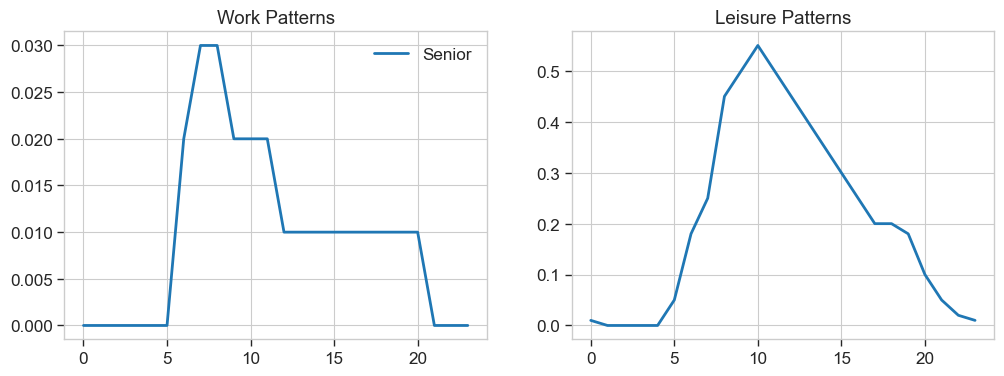

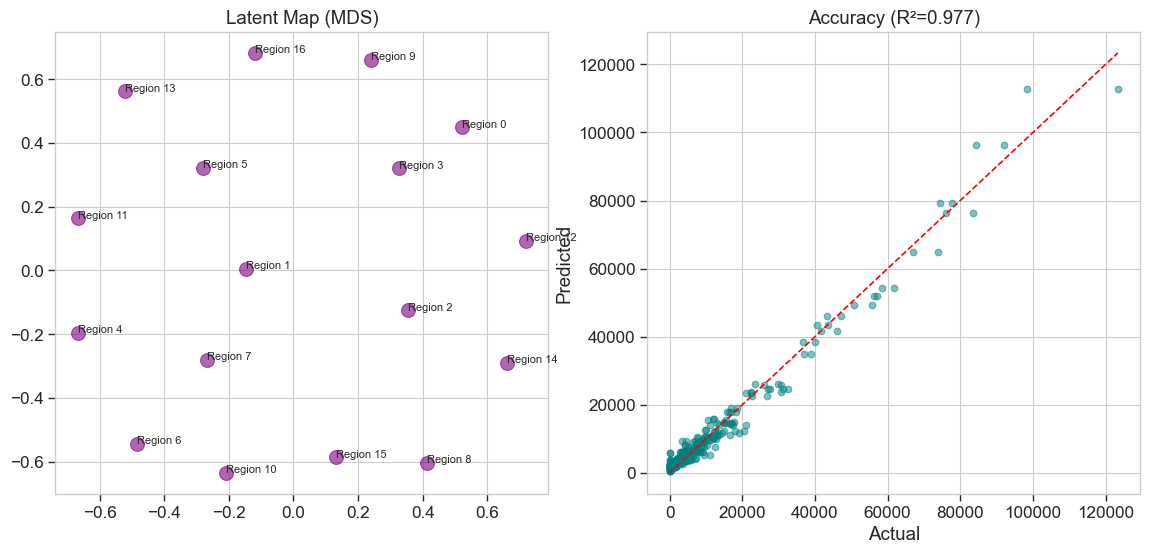

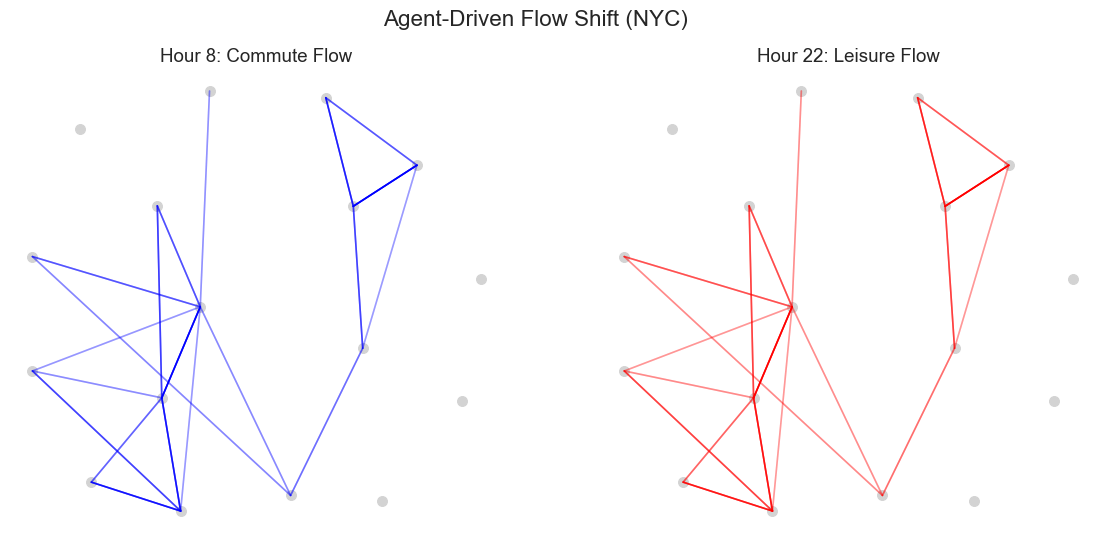


🏙️  PROCESSING: Las Vegas

📥 [DEMOGRAPHER] Fetching Real ACS Data for Las Vegas...
   ✅ Mapped 17 zones to cohorts using Real Census Data.

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: Las Vegas. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
Sociologist (to user):

{
  "0": {"sleep": 0.92, "work": 0.00, "leisure": 0.01, "home": 0.07},
  "1": {"sleep": 0.94, "work": 0.00, "leisure": 0.00, "home": 0.06},
  "2": {"sleep": 0.95, "work": 0.00, "leisure": 0.00, "home": 0.05},
  "3": {"sleep": 0.95, "work": 0.00, "leisure": 0.00, "home": 0.05},
  "4": {"sleep": 0.94, "work": 0.00, "leisure": 0.00, "home": 0.06},
  "5": {"sleep": 0.85, "work": 0.00, "leisure": 0.02, "home": 0.13},
  "6": {"sleep": 0

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Planner (to user):

{"reasoning":"Temporal drivers: 6:00 AM on a weekday is early-morning; overall city activity is ramping up but still low compared with mid-morning. In Las Vegas specifically there is a strong tourism and service-sector presence (early-shift hospitality, casino staff), but seniors as a demographic are less tied to peak commute patterns. The provided senior sleep state (0.60) implies a majority remain asleep or at-home resting at this hour. Cultural/behavioral drivers for seniors include higher sleep prevalence, occasional early medical appointments or errands, and morning walks/social activities for a minority. Safety, heat patterns (less relevant at 6 AM), and limited public transit frequency early in the day also suppress non-home mobility for seniors.","forces":{"commute":0.18,"leisure":0.14,"home":0.68}}

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (45eb7e18-c022-49cf-ab0d-187b1f8a043e): Maximum numbe

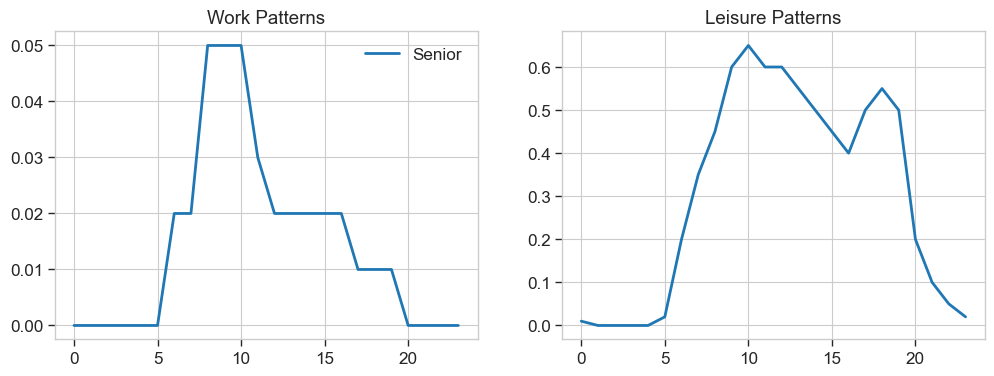

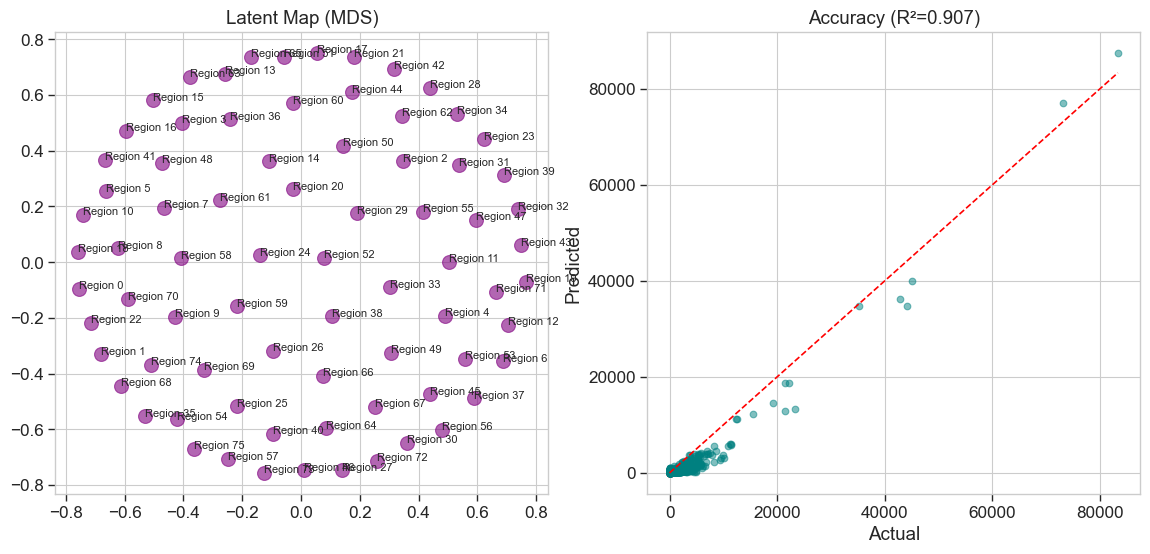

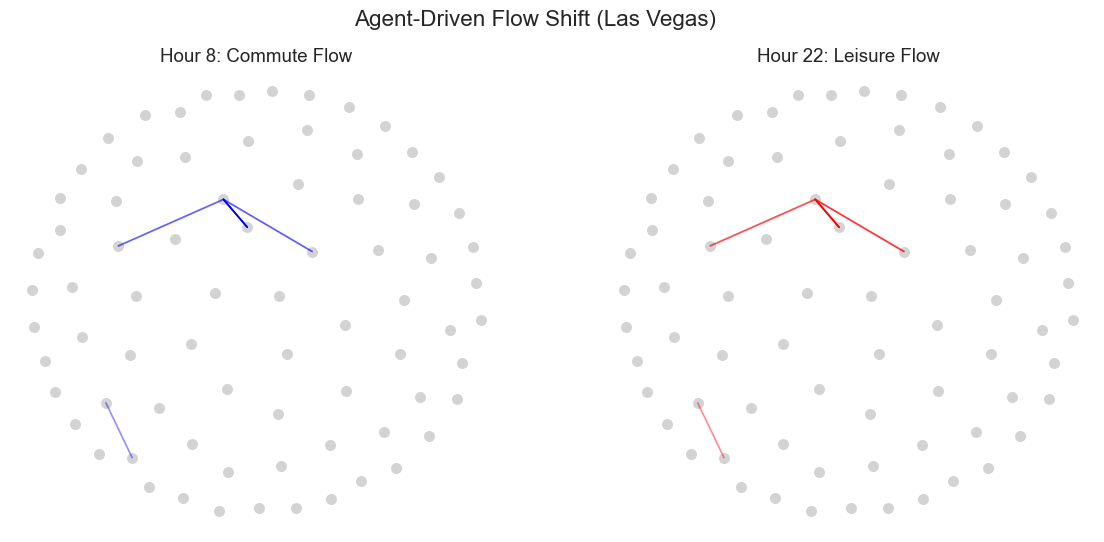


🏙️  PROCESSING: Milwaukee

📥 [DEMOGRAPHER] Fetching Real ACS Data for Milwaukee...
   ✅ Mapped 17 zones to cohorts using Real Census Data.

🧠 [SOCIOLOGIST] Modeling Lifestyles for 1 Cohorts...
user (to Sociologist):


            Context: Milwaukee. Demographic: 'Senior'.
            Task: Create 24-hour probabilities (0-23) for:
            1. 'sleep' 2. 'work' 3. 'leisure' 4. 'home'.
            Output JSON: {"0": {"sleep": 0.9, ...}, ...}
            

--------------------------------------------------------------------------------
Sociologist (to user):

{"0": {"sleep": 0.95, "work": 0.01, "leisure": 0.05, "home": 0.98}, "1": {"sleep": 0.95, "work": 0.01, "leisure": 0.04, "home": 0.99}, "2": {"sleep": 0.95, "work": 0.01, "leisure": 0.03, "home": 0.99}, "3": {"sleep": 0.94, "work": 0.01, "leisure": 0.03, "home": 0.99}, "4": {"sleep": 0.90, "work": 0.01, "leisure": 0.04, "home": 0.98}, "5": {"sleep": 0.85, "work": 0.01, "leisure": 0.06, "home": 0.98}, "6": {"sleep": 0.60, "work": 0.

/opt/homebrew/Caskroom/miniforge/base/envs/genurban/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Planner (to user):

{"reasoning":"At 06:00 on a weekday in Milwaukee the dominant drivers are early-morning routine and the onset of commuter activity, but peak commute demand usually ramps later (7–9am). Seniors as a group tend to have lower out-of-home mobility at this hour: many remain at home for rest, medication, breakfast and preparation for the day; those who go out often do short trips (walks, grocery runs, medical appointments) or use paratransit rather than regular rush-hour commuting. Local factors that depress senior mobility at 6 AM include colder Midwestern mornings in much of the year, lower transit frequency early, and safety/visibility concerns; factors that push a small amount of movement are morning exercise, early medical appointments, or caregiving pickups. Given the state probability (home 0.95), the mobility forces reflect a very strong home bias, with only a small residual for leisure and minimal commuter-oriented movement.","forces":{"commute":0.02,"leisure":0.

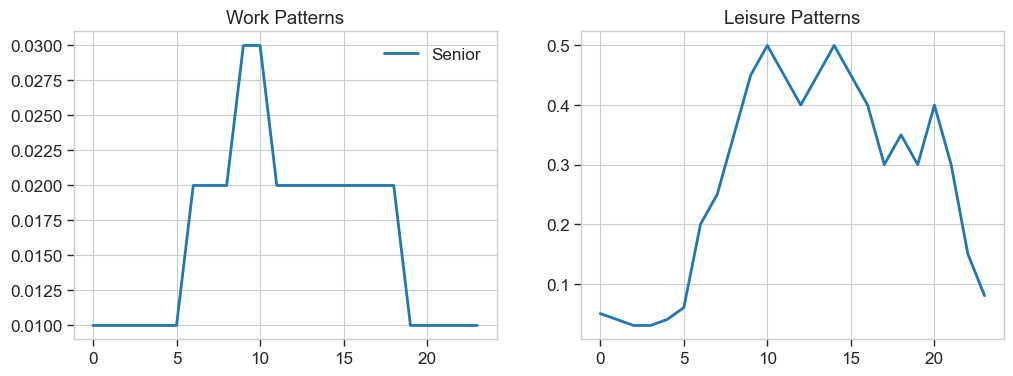

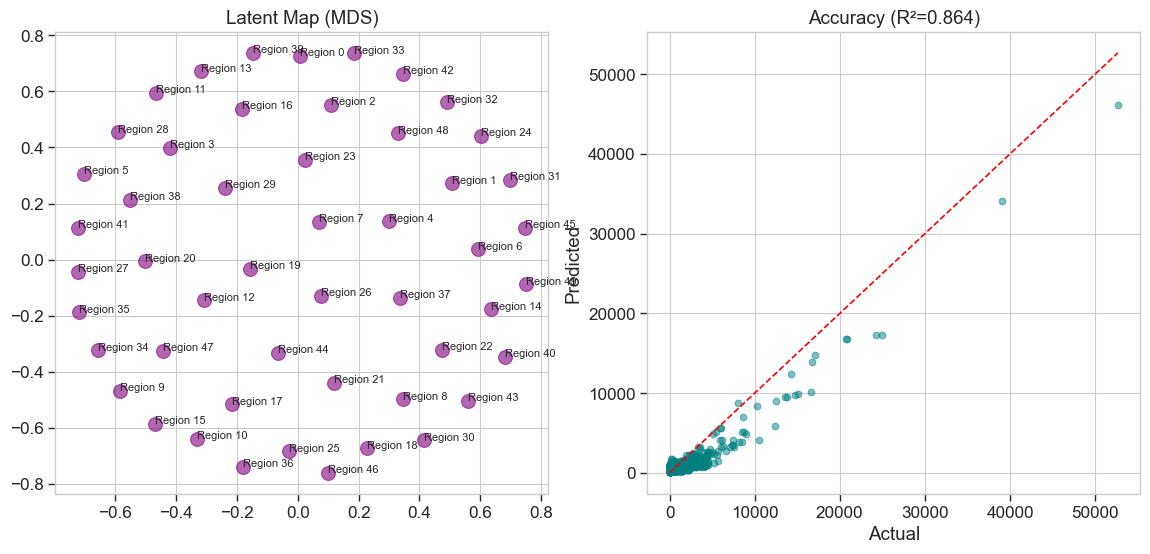

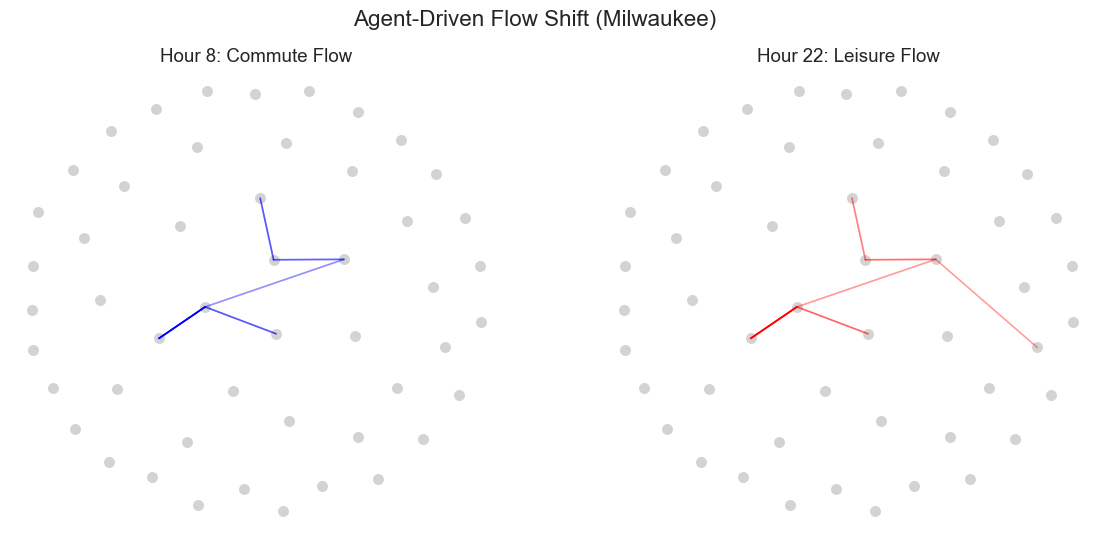

In [22]:
# ==============================================================================
# 🏁 CELL 7: EXECUTION LOOP
# ==============================================================================
cities_db = {
    "NYC": {
        "train": ["New-york-city-boroughs/new-york-city-boroughs.geojson Flow 6-9.csv", "New-york-city-boroughs/new-york-city-boroughs.geojson Flow 10-13.csv", "New-york-city-boroughs/new-york-city-boroughs.geojson Flow 14-17.csv", "New-york-city-boroughs/new-york-city-boroughs.geojson Flow 18-21.csv"],
        "test": "New-york-city-boroughs/new-york-city-boroughs.geojson Flow 22-25.csv",
        "county": "061", "state": "36",
        "bbox": (-74.047736, 40.674144, -73.884672, 40.901888),
        "geojson": "New-york-city-boroughs/new-york-city-boroughs.geojson"
    },
    "Las Vegas": {
        "train": ["LasVegas/lasvagas.geojson Flow 6-9.csv", "LasVegas/lasvagas.geojson Flow 10-13.csv", "LasVegas/lasvagas.geojson Flow 14-17.csv", "LasVegas/lasvagas.geojson Flow 18-21.csv"],
        "test": "LasVegas/lasvagas.geojson Flow 22-25.csv",
        "county": "003", "state": "32",
        "bbox": (-115.424285, 36.129554, -115.047765, 36.380841),
        "geojson": "LasVegas/lasvagas.geojson"
    },
    "Milwaukee": {
        "train": ["Milwaukee/milwaukee.geojson Flow 6-9.csv", "Milwaukee/milwaukee.geojson Flow 10-13.csv", "Milwaukee/milwaukee.geojson Flow 14-17.csv", "Milwaukee/milwaukee.geojson Flow 18-21.csv"],
        "test": "Milwaukee/milwaukee.geojson Flow 22-25.csv",
        "county": "079", "state": "55", 
        "bbox": (-88.083329, 42.917583, -87.862713, 43.200599),
        "geojson": "Milwaukee/milwaukee.geojson"
    }
}

for city, data in cities_db.items():
    print(f"\n" + "="*50 + f"\n🏙️  PROCESSING: {city}\n" + "="*50)
    
    # 1. Real Data Ingestion
    profs = demo.ingest_census(city, data['county'], data['state'])
    soc.generate_schedules(city, profs)
    
    # 2. Build Engine
    eng = HardDataEngine(city, soc, plan)
    
    # Pass DYNAMIC BBOX to override Utl.py's hardcoded values
    eng.ingest_buildings_dynamic(data['bbox'], data['geojson'])
    eng.learn_topology(data['train'])
    
    # 3. Train & Test
    r2, true, pred = eng.train_and_test(data['train'], data['test'])
    print(f"\n🏆 {city} R²: {r2:.4f}")
    
    # 4. Viz
    plot_results(city, eng, r2, true, pred, soc)